- Use appropriate commands in python to split the data into a training set and a test set. 
- How well does each model predict the data? Construct different neural networks, 
- is it possible to visualise the model and are there ways to improve performance?

#### Objective

**You’ll:**
- Split the dataset into training and test sets
- Train several neural networks with different architectures
- Evaluate performance (accuracy, misclassifications)
- Visualize decision boundaries
- Discuss how to improve performance
- We’ll use make_moons (nonlinear dataset) because it clearly shows the power of neural networks.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from matplotlib.colors import ListedColormap, Normalize


In [4]:
# Generate nonlinear data
X, y = make_moons(n_samples=200, noise=0.25, random_state=0)

# Split into training and test sets (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (140, 2)
Test set size: (60, 2)


#### Define a Helper Function for Visualization
We’ll visualize the decision boundary learned by each NN.

In [5]:
def plot_decision_boundary(model, X, y, title):
    h = 0.02  # mesh step size
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cmap_light = ListedColormap(['#FFBBBB', '#BBFFBB'])
    cmap_bold = ['red', 'green']

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(cmap_bold), edgecolor='k')
    plt.title(title)
    plt.show()

##### Build and Train Different Neural Networks
### Model 1 — No Hidden Layers (like Logistic Regression)

Accuracy (no hidden layers): 0.77


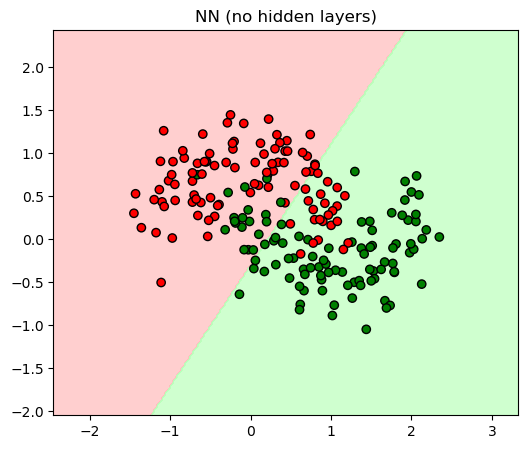

In [6]:
mlp1 = MLPClassifier(hidden_layer_sizes=(),
                     activation='logistic',
                     max_iter=2000, random_state=0)
mlp1.fit(X_train, y_train)

print("Accuracy (no hidden layers): %.2f" % mlp1.score(X_test, y_test))
plot_decision_boundary(mlp1, X, y, "NN (no hidden layers)")


#### Observation:
- The model tries to draw a straight line to separate the data.
- Fails to capture the curved shape — low accuracy.

#### Model 2 — One Hidden Layer (10 Neurons)

Accuracy (1 hidden layer): 0.83


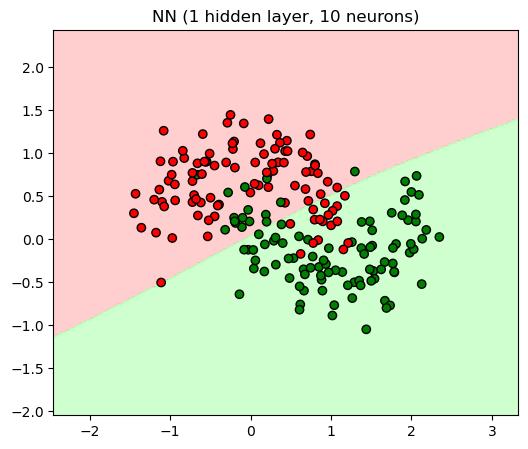

In [7]:
mlp2 = MLPClassifier(hidden_layer_sizes=(10,),
                     activation='tanh',
                     max_iter=2000, random_state=0)
mlp2.fit(X_train, y_train)

print("Accuracy (1 hidden layer): %.2f" % mlp2.score(X_test, y_test))
plot_decision_boundary(mlp2, X, y, "NN (1 hidden layer, 10 neurons)")


#### Observation:
- The model learns curved boundaries — fits the moon shapes better.
- Accuracy improves significantly.

### Model 3 — Deep Neural Network (3 Hidden Layers)

Accuracy (3 hidden layers): 0.93


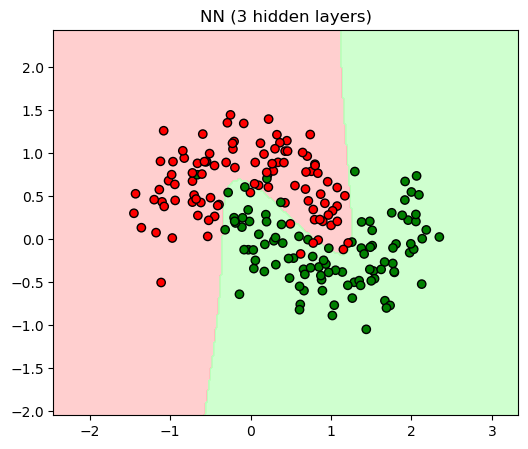

In [8]:
mlp3 = MLPClassifier(hidden_layer_sizes=(20, 40, 20),
                     activation='tanh',
                     max_iter=3000, random_state=0)
mlp3.fit(X_train, y_train)

print("Accuracy (3 hidden layers): %.2f" % mlp3.score(X_test, y_test))
plot_decision_boundary(mlp3, X, y, "NN (3 hidden layers)")


#### Observation:
- The model captures the complex structure very well.
- The decision boundary wraps around the data perfectly.
- High accuracy, but be cautious of overfitting (fits training data too well).